In [1]:
# Cell 1: imports

from functools import partial

import torch
from torch import nn

from base_range_library import range_library
from dataset import StreamingGeometryDatasetConfig, make_streaming_dataloader
from utils import (
    TrainConfig,
    fit,
    make_optimizer,
    mse_loss,
    webster_batch_to_xy,
    plot_history,
)
from models.fno import TransferFunctionFNO, webster_fno_batch_to_xy

In [2]:
# Cell 2: общие параметры

device = "cuda" if torch.cuda.is_available() else "cpu"

batch_size = 32
n_profile_points = 128
n_frequencies = 256

steps_per_epoch = 10
val_steps = 8
epochs = 10

train_config = StreamingGeometryDatasetConfig(
    geometry_kind="random",
    target_mode="db",
    seed=1,
)

val_config = StreamingGeometryDatasetConfig(
    geometry_kind="random",
    target_mode="db",
    seed=100_000,
    max_samples=batch_size * val_steps,
)

In [3]:
# Cell 3: dataloaders

train_loader = make_streaming_dataloader(
    train_config,
    range_library,
    batch_size=batch_size,
    num_workers=0,
)

val_loader = make_streaming_dataloader(
    val_config,
    range_library,
    batch_size=batch_size,
    num_workers=0,
)

In [4]:
# Cell 4: MLP model

class ProfileMLP(nn.Module):
    def __init__(
        self,
        n_profile_points: int,
        in_channels: int,
        n_frequencies: int,
        hidden_dim: int = 512,
        depth: int = 4,
        dropout: float = 0.05,
    ):
        super().__init__()

        input_dim = n_profile_points * in_channels

        layers = [
            nn.Flatten(),
            nn.Linear(input_dim, hidden_dim),
            nn.GELU(),
            nn.LayerNorm(hidden_dim),
        ]

        for _ in range(depth - 1):
            layers += [
                nn.Linear(hidden_dim, hidden_dim),
                nn.GELU(),
                nn.Dropout(dropout),
            ]

        layers.append(nn.Linear(hidden_dim, n_frequencies))

        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

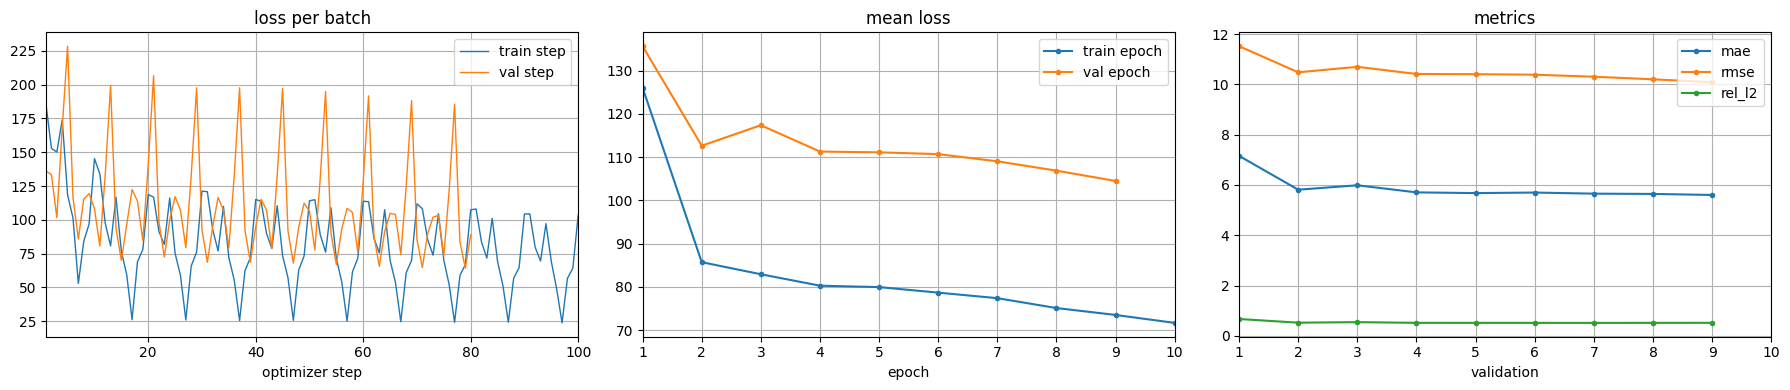

epoch 010/10 | train=71.7074 | val=102.889 | lr=0.001


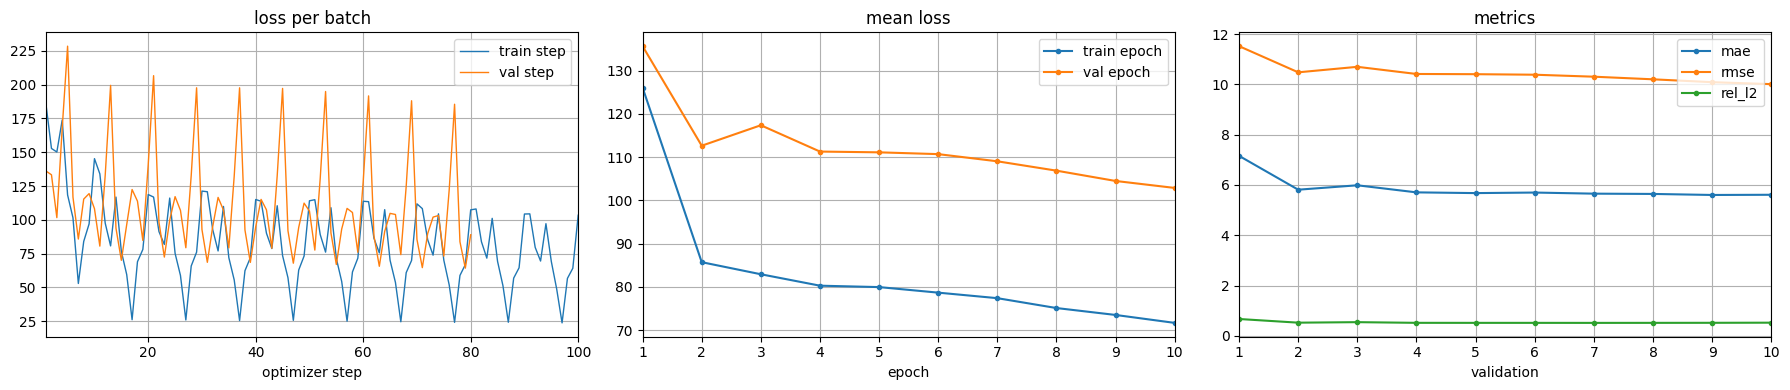

In [5]:
# Cell 5: train MLP

mlp_batch_to_xy = partial(
    webster_batch_to_xy,
    n_points=n_profile_points,
    log_area=True,
    include_x=True,
    channel_first=False,
)

mlp = ProfileMLP(
    n_profile_points=n_profile_points,
    in_channels=2,  # log(area), x
    n_frequencies=n_frequencies,
).to(device)

mlp_optimizer = make_optimizer(
    mlp,
    lr=1e-3,
    weight_decay=1e-4,
)

mlp_history = fit(
    mlp,
    mlp_optimizer,
    train_loader,
    val_loader,
    criterion=mse_loss,
    batch_to_xy=mlp_batch_to_xy,
    config=TrainConfig(
        epochs=epochs,
        steps_per_epoch=steps_per_epoch,
        val_steps=val_steps,
        device=device,
        show_progress=False,
        live_plot_every_steps=1,
        grad_clip_norm=1.0,
    ),
)

plot_history(mlp_history)

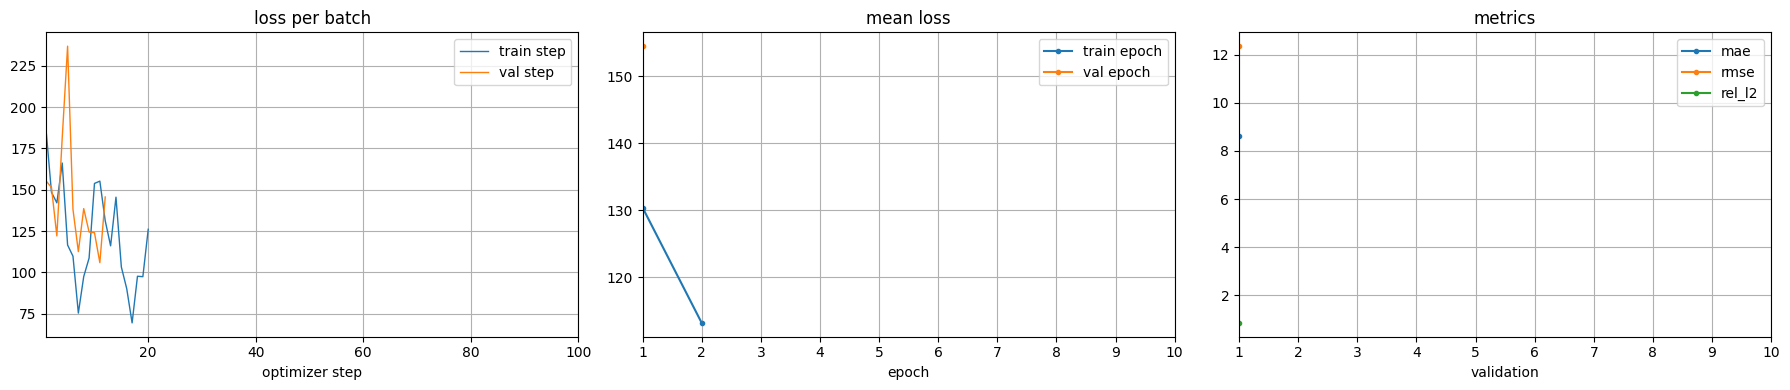

KeyboardInterrupt: 

In [6]:
# Cell 6: train FNO

fno_batch_to_xy = partial(
    webster_fno_batch_to_xy,
    n_points=n_profile_points,
    log_area=True,
)

fno = TransferFunctionFNO(
    n_modes=24,
    hidden_channels=64,
    latent_dim=128,
    pooling_bins=8,
    frequency_bands=8,
    out_channels=1,  # dB: output shape [B, Nf]
).to(device)

fno_optimizer = make_optimizer(
    fno,
    lr=1e-3,
    weight_decay=1e-4,
)

fno_history = fit(
    fno,
    fno_optimizer,
    train_loader,
    val_loader,
    criterion=mse_loss,
    batch_to_xy=fno_batch_to_xy,
    config=TrainConfig(
        epochs=epochs,
        steps_per_epoch=steps_per_epoch,
        val_steps=val_steps,
        device=device,
        show_progress=False,
        live_plot_every_steps=1,
        grad_clip_norm=1.0,
    ),
)

plot_history(fno_history)

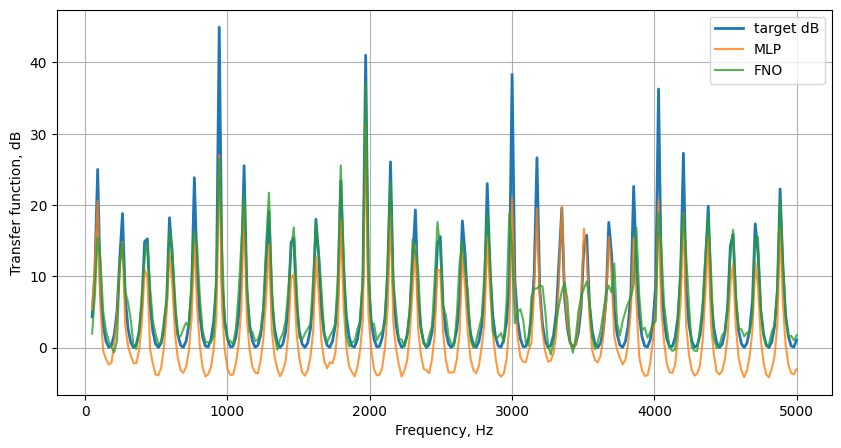

In [ ]:
# Cell 7: сравнение на одном батче

import matplotlib.pyplot as plt

batch = next(iter(val_loader))

with torch.no_grad():
    x_mlp, y = mlp_batch_to_xy(batch, torch.device(device))
    pred_mlp = mlp(x_mlp)

    x_fno, _ = fno_batch_to_xy(batch, torch.device(device))
    pred_fno = fno(*x_fno)

freq = batch["frequencies_hz"][0].cpu()
target = y[0].cpu()
mlp_pred = pred_mlp[0].cpu()
fno_pred = pred_fno[0].cpu()

plt.figure(figsize=(10, 5))
plt.plot(freq, target, label="target dB", linewidth=2)
plt.plot(freq, mlp_pred, label="MLP", alpha=0.8)
plt.plot(freq, fno_pred, label="FNO", alpha=0.8)
plt.xlabel("Frequency, Hz")
plt.ylabel("Transfer function, dB")
plt.grid(True)
plt.legend()
plt.show()